In [6]:
%cd ../
from src.data_loader import CoffeeDataset
from src.region_extraction import extract_region
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import pywt

class TransformedDataset(CoffeeDataset):
    def __init__(self, split):
        super().__init__(split)
        
    def __getitem__(self, item):
        img, label = super().__getitem__(item)
        return extract_region(np.asarray(img), cropping=False), label

dataset = TransformedDataset("train")

C:\Users\erny


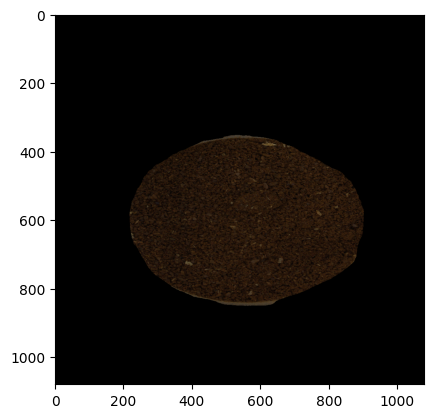

In [17]:
plt.imshow(dataset[92][0])

C:\Users\erny\AppData\Local\Temp\ipykernel_7048\711043293.py:7: RuntimeWarning: invalid value encountered in log1p
  im0 = ax[0,0].imshow(np.log1p(coeffs[0]))
C:\Users\erny\AppData\Local\Temp\ipykernel_7048\711043293.py:10: RuntimeWarning: invalid value encountered in log1p
  im1 = ax[1,0].imshow(np.log1p(coeffs[1][0]))
C:\Users\erny\AppData\Local\Temp\ipykernel_7048\711043293.py:13: RuntimeWarning: divide by zero encountered in log1p
  im2 = ax[1,1].imshow(np.log1p(coeffs[1][1]))
C:\Users\erny\AppData\Local\Temp\ipykernel_7048\711043293.py:13: RuntimeWarning: invalid value encountered in log1p
  im2 = ax[1,1].imshow(np.log1p(coeffs[1][1]))
C:\Users\erny\AppData\Local\Temp\ipykernel_7048\711043293.py:16: RuntimeWarning: invalid value encountered in log1p
  im3 = ax[0,1].imshow(np.log1p(coeffs[1][2]))


15.978267582190204
0.010985743691393882 tensor(0.2960)


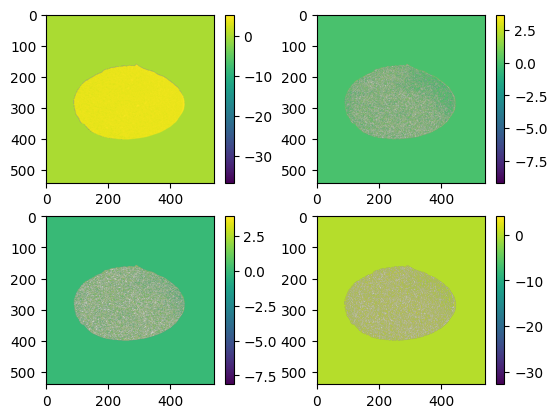

In [8]:
import pywt
from skimage.measure import shannon_entropy

img, fineness = dataset[50]
coeffs = pywt.dwt2(img.mean(axis=-1), 'Db2')
fig, ax = plt.subplots(2, 2)
im0 = ax[0,0].imshow(np.log1p(coeffs[0]))
fig.colorbar(im0, ax=ax[0,0])

im1 = ax[1,0].imshow(np.log1p(coeffs[1][0]))
fig.colorbar(im1, ax=ax[1,0])

im2 = ax[1,1].imshow(np.log1p(coeffs[1][1]))
fig.colorbar(im2, ax=ax[1,1])

im3 = ax[0,1].imshow(np.log1p(coeffs[1][2]))
fig.colorbar(im3, ax=ax[0,1])

cf = coeffs[1][0]
print(shannon_entropy(cf[cf != 0]))
print(cf[cf != 0].mean(), fineness)

100%|██████████| 489/489 [01:12<00:00,  6.78it/s]


[[ 1.         -0.41905294]
 [-0.41905294  1.        ]]


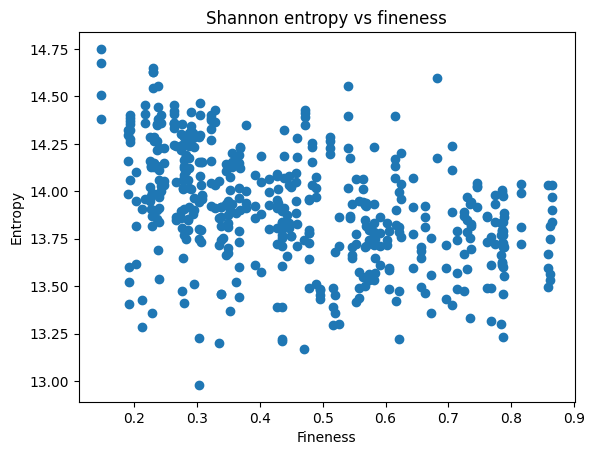

In [18]:
outs = []

for img, fineness in tqdm.tqdm(dataset):
    coeffs = pywt.dwt2(img.mean(axis=-1), 'haar')
    cf = (coeffs[1][0]**2 + coeffs[1][1]**2 + coeffs[1][2]**2) / 3
    hv = shannon_entropy(cf[cf != 0])
    outs.append((hv, fineness))

out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])
plt.title("Shannon entropy vs fineness")
plt.xlabel("Fineness")
plt.ylabel("Entropy")
print(np.corrcoef(out[:, 0], out[:, 1]))


100%|██████████| 489/489 [01:14<00:00,  6.54it/s]


[[ 1.        -0.4969479]
 [-0.4969479  1.       ]]


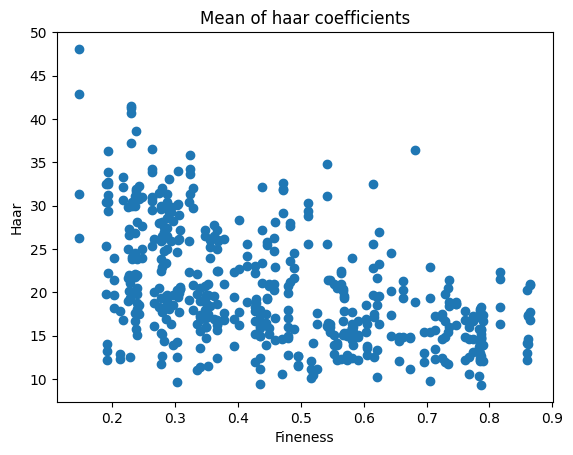

In [9]:
outs = []

for img, fineness in tqdm.tqdm(dataset):
    coeffs = pywt.dwt2(img.mean(axis=-1), 'haar')
    cf = (coeffs[1][0]**2 + coeffs[1][1]**2 + coeffs[1][2]**2)/3
    hv = cf[cf != 0].mean()
    outs.append((hv, fineness))
    
out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])
plt.title("Mean of haar coefficients")
plt.xlabel("Fineness")
plt.ylabel("Haar")

print(np.corrcoef(out[:,0], out[:, 1]))

100%|██████████| 489/489 [01:13<00:00,  6.69it/s]


[[ 1.         -0.41905294]
 [-0.41905294  1.        ]]


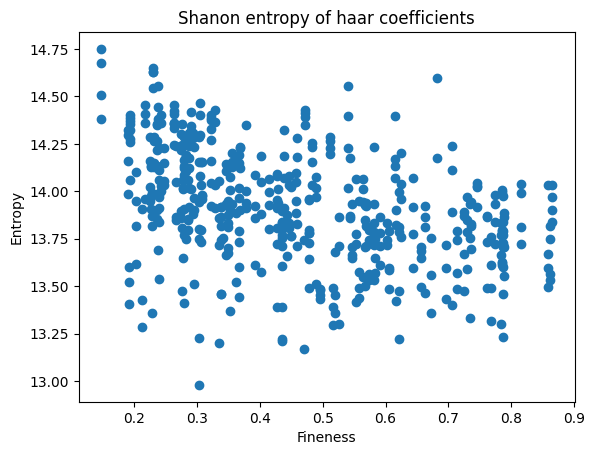

In [10]:
outs = []

for img, fineness in tqdm.tqdm(dataset):
    coeffs = pywt.dwt2(img.mean(axis=-1), 'haar')
    cf = (coeffs[1][0]**2 + coeffs[1][1]**2 + coeffs[1][2]**2)/3
    hv = shannon_entropy(cf[cf != 0])#cf[cf != 0].mean()
    outs.append((hv, fineness))
    
out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])
plt.title("Shanon entropy of haar coefficients")
plt.xlabel("Fineness")
plt.ylabel("Entropy")
print(np.corrcoef(out[:,0], out[:, 1])) # weak correlation

[[ 1.         -0.32241714]
 [-0.32241714  1.        ]]


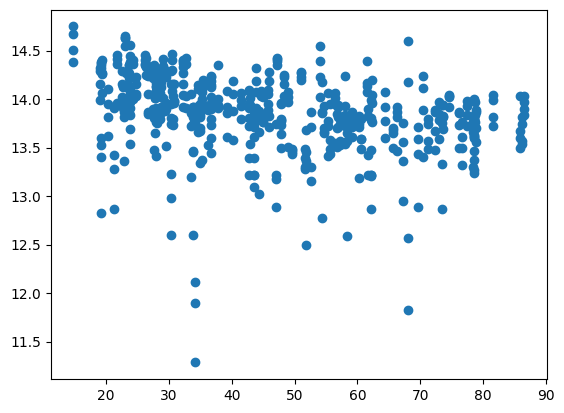

In [38]:
out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])

print(np.corrcoef(out[:,0], out[:, 1])) # some correlation

In [39]:
f = np.fft.fft2(img.mean(axis=-1))
fshift = np.fft.fftshift(f)

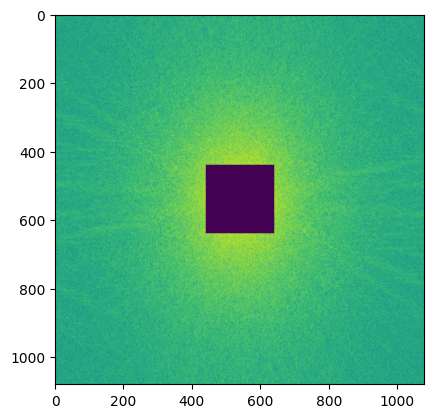

In [40]:
mask = np.ones_like(img[..., 0])
center_rows = img.shape[0]//2
center_cols = img.shape[1]//2
mask[center_rows-100:center_rows+100, center_cols-100: center_cols+100] = 0
plt.imshow(np.log(np.abs(fshift)) * mask)

100%|██████████| 520/520 [02:28<00:00,  3.51it/s]

[[ 1.         -0.01071692]
 [-0.01071692  1.        ]]


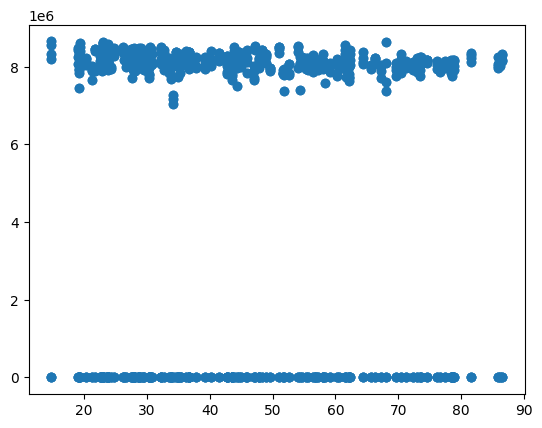

In [42]:
for img, fineness in tqdm.tqdm(dataset): # does not really work, leaving for the future
    mask = np.ones_like(img[..., 0])
    center_rows = img.shape[0]//2
    center_cols = img.shape[1]//2
    mask[center_rows-100:center_rows+100, center_cols-100: center_cols+100] = 0
    f = np.fft.fft2(img.mean(axis=-1))
    fshift = np.fft.fftshift(f)
    o = np.log(np.abs(fshift)) * mask
    outs.append((o.sum(), fineness))
    
out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])

print(np.corrcoef(out[:,0], out[:, 1]))

0.7691711098309849
tensor(23.7000)
2.6530611210945128
17.601879119873047


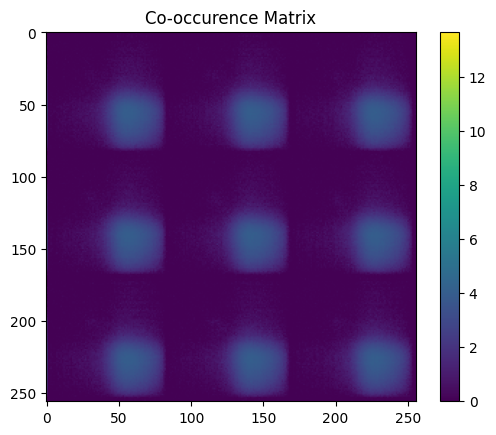

In [43]:
from skimage.feature import graycomatrix, graycoprops
img, fineness = dataset[29]
edges = graycomatrix((255*img.mean(axis=-1)).astype("uint8"), [5, 10, 15], [0, 45, 90, 135])
print(graycoprops(edges, 'homogeneity').mean())
plt.imshow(np.log1p(edges.mean(axis=(-1,-2))))
plt.title("Co-occurence Matrix")
plt.colorbar()
print(fineness)
print(shannon_entropy(edges))
print(edges.mean())

100%|██████████| 520/520 [01:44<00:00,  4.98it/s]

[[1.         0.17751313]
 [0.17751313 1.        ]]


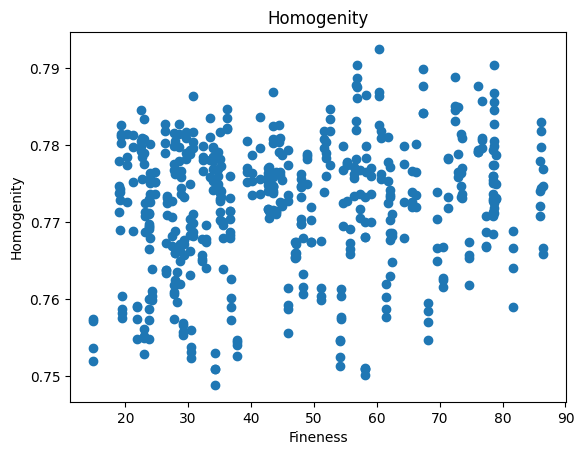

In [44]:
outs = []

for img, fineness in tqdm.tqdm(dataset):
    edges = graycomatrix((255*img.mean(axis=-1)).astype("uint8"), [5, 10, 15], [0, 45, 90, 135])
    hv = graycoprops(edges, 'homogeneity').mean()
    outs.append((hv, fineness))
    
out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])
plt.title("Homogenity")
plt.xlabel("Fineness")
plt.ylabel("Homogenity")
print(np.corrcoef(out[:,0], out[:, 1])) # weak correlation

100%|██████████| 489/489 [01:09<00:00,  7.08it/s]


[[ 1.         -0.36548066]
 [-0.36548066  1.        ]]


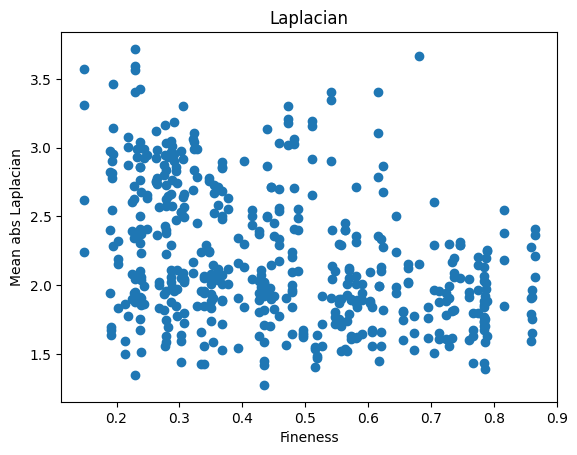

In [19]:
from scipy.ndimage import laplace

outs = []

for img, fineness in tqdm.tqdm(dataset):
    gray = img.mean(axis=-1)
    lap = laplace(gray)
    hv = np.abs(lap).mean()
    outs.append((hv, fineness))

out = np.asarray(outs)
plt.scatter(out[:, 1], out[:, 0])
plt.title("Laplacian")
plt.xlabel("Fineness")
plt.ylabel("Mean abs Laplacian")
print(np.corrcoef(out[:, 0], out[:, 1]))
